# Блок 4. Задача 1: метод главных компонент (PCA)

Цель: сократить размерность признаков на датасете `Digits` и визуализировать объекты в пространстве главных компонент.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")


## Загрузка и анализ данных


In [7]:
digits = load_digits()
X = digits.data
y = digits.target

df_digits = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])
df_digits["target"] = y

display(df_digits.head())
print("Размер датасета:", df_digits.shape)
print("Количество признаков:", X.shape[1])


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


Размер датасета: (1797, 65)
Количество признаков: 64


## Стандартизация и PCA


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)
print("Компонент для 95% дисперсии:", n_components_95)


Компонент для 95% дисперсии: 40


## График объяснённой дисперсии


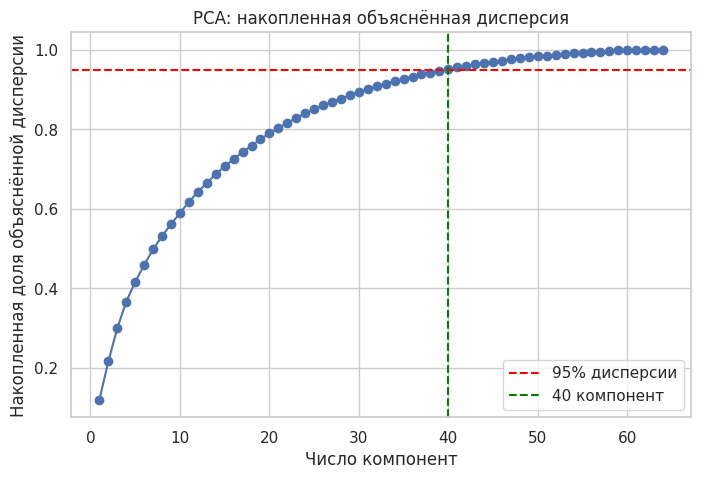

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% дисперсии")
plt.axvline(n_components_95, color="green", linestyle="--", label=f"{n_components_95} компонент")
plt.xlabel("Число компонент")
plt.ylabel("Накопленная доля объяснённой дисперсии")
plt.title("PCA: накопленная объяснённая дисперсия")
plt.legend()
plt.show()


## Визуализация в двух компонентах


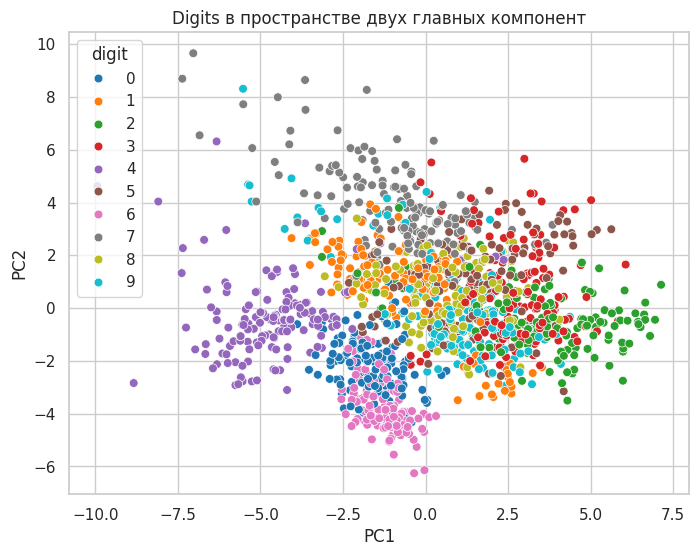

In [10]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_scaled)

plot_df = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "digit": y_train})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="digit", palette="tab10", s=40)
plt.title("Digits в пространстве двух главных компонент")
plt.show()


## Вывод

Входные данные соответствуют задаче сокращения размерности: используется датасет `Digits` размером `1797 x 65`, в `X` входят `64` пиксельных признака изображения `8 x 8`, а `target` используется только как метка класса для анализа и визуализации. Перед PCA признаки стандартизированы.

По текущему запуску для сохранения `95 %` дисперсии потребовалось `40` главных компонент из исходных `64` признаков. Это означает, что PCA позволяет уменьшить размерность пространства признаков примерно на треть, сохранив большую часть информации по дисперсии.

Двумерная визуализация по первым двум главным компонентам удобна для просмотра структуры данных, но она не сохраняет все `95 %` дисперсии. Основной результат задачи - определение числа компонент `40` для заданного порога сохранённой дисперсии.
